# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdelrahmanshaheen1/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can search-performance signals observed during March 2026 help rank webpages that are more likely to experience a meaningful impressions decline in April 2026?

This project supports a practical content decision: when a content or SEO team has more webpages than it can inspect manually, which pages should be reviewed first?

The system is designed as a ranking and decision-support tool. Each page receives a decline score, and the highest-ranked pages are reviewed first by a human. The reviewer may then decide to investigate click-through rate, ranking relevance, content freshness, or other page-specific issues.

The goal is not to predict Google's algorithm or automatically change content. The goal is to test whether a small, public-safe set of measured search signals can produce a more useful review queue than a transparent hand-written baseline.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This project uses the protected FlyRank ML Internship warehouse dataset and focuses on the daily content-performance table `fact_content_daily_performance`.

The feature window is **March 1–31, 2026**. Only information available by the end of March is used as model input.

The outcome window is **April 1–30, 2026**. April information is used only to construct the future decline label and evaluate the ranking.

The final unit of analysis is one pseudonymized webpage or content item for one client.

The five model features are:

- `march_impressions`
- `march_clicks`
- `march_ctr_pct`
- `march_avg_position`
- `march_active_days`

Pages are included only when they have at least 100 March impressions and are observed in April. This minimum-evidence rule reduces extremely sparse cases.

The provisional outcome is `is_next_month_decline`. It equals 1 when April impressions are more than 20% below March impressions, and 0 otherwise.

Several fields are deliberately excluded from the model. April measurements are excluded because they occur after the decision moment. The future decline label itself is never used as an input. Client and content identifiers are used only for grouping, joining, and validation. GA4 behavior fields are excluded from this first model because coverage is incomplete for some clients and periods.

No real client names, page URLs, search queries, or other private identifiers are used in the public analysis.

In [ ]:
%pip -q install duckdb huggingface_hub

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found. Check Colab Secrets."
    )

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

APRIL_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-04/*.parquet'"
    f")"
)

feature_frame = con.sql(f"""
    WITH march_features AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(COALESCE(gsc_impressions, 0))
                AS march_impressions,

            SUM(COALESCE(gsc_clicks, 0))
                AS march_clicks,

            ROUND(
                100.0 *
                SUM(COALESCE(gsc_clicks, 0)) /
                NULLIF(
                    SUM(COALESCE(gsc_impressions, 0)),
                    0
                ),
                4
            ) AS march_ctr_pct,

            AVG(
                CASE
                    WHEN gsc_impressions > 0
                         AND gsc_avg_position > 0
                    THEN gsc_avg_position
                END
            ) AS march_avg_position,

            COUNT(
                DISTINCT CASE
                    WHEN gsc_impressions > 0
                    THEN report_date
                END
            ) AS march_active_days

        FROM {MARCH_DAILY}

        GROUP BY
            client_hash_id,
            content_hash_id

        HAVING
            SUM(COALESCE(gsc_impressions, 0)) >= 100
    ),

    april_outcomes AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(COALESCE(gsc_impressions, 0))
                AS april_impressions,

            COUNT(DISTINCT report_date)
                AS april_observed_days

        FROM {APRIL_DAILY}

        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        m.*,
        a.april_impressions,

        CASE
            WHEN a.april_impressions
                 < 0.80 * m.march_impressions
            THEN 1
            ELSE 0
        END AS is_next_month_decline

    FROM march_features AS m

    INNER JOIN april_outcomes AS a
        USING (
            client_hash_id,
            content_hash_id
        )

    WHERE a.april_observed_days > 0
""").df()

FEATURES = [
    "march_impressions",
    "march_clicks",
    "march_ctr_pct",
    "march_avg_position",
    "march_active_days",
]

print(f"Final page-level rows: {len(feature_frame):,}")
print(f"Pseudonymized clients: {feature_frame['client_hash_id'].nunique():,}")
print(
    "Observed next-month decline rate: "
    f"{feature_frame['is_next_month_decline'].mean():.1%}"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final page-level rows: 101,441
Pseudonymized clients: 44
Observed next-month decline rate: 51.7%


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The task is a ranking problem. Each webpage receives a score representing how strongly its March signals resemble pages that later experienced a meaningful impressions decline in April. Pages with higher scores are reviewed first.

The final model is **Logistic Regression**. I also tested a Random Forest, but the simpler Logistic Regression produced the strongest measured ranking performance on the grouped-client holdout. Complexity was therefore not rewarded for its own sake.

The five honest model features are:

- `march_impressions`
- `march_clicks`
- `march_ctr_pct`
- `march_avg_position`
- `march_active_days`

The target is `is_next_month_decline`:

- `1` when April impressions are more than 20% lower than March impressions
- `0` otherwise

A transparent Week-4 baseline is used for comparison. The baseline ranks pages using weak CTR relative to other pages in similar search-position buckets.

Validation is grouped by `client_hash_id`. Entire clients are held out, so pages from the same client do not appear in both training and testing. This is intended to provide a stronger estimate of how the ranking generalizes to unseen clients.

The main metric is **Precision@50**, with Precision@20 reported as a second ranking metric. Precision@50 measures the share of truly declining pages among the top 50 ranked recommendations.

A leakage audit confirmed that all model inputs are available by the end of March and contain no April or target-derived information. April impressions are used only to construct the future label and evaluate the ranking.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def precision_at_k(y_true, scores, k):
    y_array = np.asarray(y_true)
    score_array = np.asarray(scores)
    actual_k = min(k, len(y_array))
    top_indices = np.argsort(score_array)[-actual_k:]
    return y_array[top_indices].mean()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42,
)

train_idx, test_idx = next(
    splitter.split(
        feature_frame,
        groups=feature_frame["client_hash_id"],
    )
)

train_df = feature_frame.iloc[train_idx].copy()
test_df = feature_frame.iloc[test_idx].copy()

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

y_train = train_df["is_next_month_decline"]
y_test = test_df["is_next_month_decline"]

client_overlap = len(
    set(train_df["client_hash_id"])
    & set(test_df["client_hash_id"])
)

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows: {len(test_df):,}")
print(f"Client overlap: {client_overlap}")

Training rows: 93,085
Testing rows: 8,356
Client overlap: 0


In [ ]:
# Logistic Regression

logistic_model = Pipeline(
    steps=[
        (
            "missing_values",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

logistic_scores = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_p20 = precision_at_k(
    y_test,
    logistic_scores,
    20,
)

logistic_p50 = precision_at_k(
    y_test,
    logistic_scores,
    50,
)


# Random Forest

random_forest_model = Pipeline(
    steps=[
        (
            "missing_values",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(X_train, y_train)

rf_scores = random_forest_model.predict_proba(
    X_test
)[:, 1]

rf_p20 = precision_at_k(
    y_test,
    rf_scores,
    20,
)

rf_p50 = precision_at_k(
    y_test,
    rf_scores,
    50,
)

print(
    f"Logistic Regression P@20={logistic_p20:.3f}, "
    f"P@50={logistic_p50:.3f}"
)

print(
    f"Random Forest P@20={rf_p20:.3f}, "
    f"P@50={rf_p50:.3f}"
)

Logistic Regression P@20=0.850, P@50=0.700
Random Forest P@20=0.750, P@50=0.580


In [ ]:
baseline_train = train_df.copy()
baseline_test = test_df.copy()

position_bins = [0, 3, 10, 20, 50, np.inf]

position_labels = [
    "top_3",
    "positions_4_10",
    "positions_11_20",
    "positions_21_50",
    "positions_51_plus",
]

# Create the same position buckets
# for training and testing data.
baseline_train["position_bucket"] = pd.cut(
    baseline_train["march_avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True,
)

baseline_test["position_bucket"] = pd.cut(
    baseline_test["march_avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True,
)

# Calculate median CTR using TRAINING data only.
# This keeps the test data unseen when the rule is constructed.
bucket_medians = (
    baseline_train
    .groupby(
        "position_bucket",
        observed=True,
    )["march_ctr_pct"]
    .median()
)

# Apply those training medians to test pages.
baseline_test["position_bucket_median_ctr"] = (
    baseline_test["position_bucket"]
    .map(bucket_medians)
    .astype(float)
)

supported_buckets = [
    "top_3",
    "positions_4_10",
    "positions_11_20",
]

# Measure how far each page's CTR falls
# below the median CTR for similar positions.
baseline_test["ctr_gap_ratio"] = np.where(
    baseline_test["position_bucket"].isin(
        supported_buckets
    )
    & baseline_test[
        "position_bucket_median_ctr"
    ].gt(0),

    (
        (
            baseline_test[
                "position_bucket_median_ctr"
            ]
            - baseline_test["march_ctr_pct"]
        )
        / baseline_test[
            "position_bucket_median_ctr"
        ]
    ).clip(
        lower=0,
        upper=1,
    ),

    0.0,
)

# Transparent baseline score.
baseline_test["baseline_score"] = np.where(
    baseline_test["position_bucket"].isin(
        supported_buckets
    )
    & (
        baseline_test["march_ctr_pct"]
        < baseline_test[
            "position_bucket_median_ctr"
        ]
    ),

    100
    * baseline_test["ctr_gap_ratio"],

    0.0,
)

# --------------------------------------------------
# Deterministic ranking
# --------------------------------------------------
# Many pages can receive exactly the same baseline
# score, especially pages with zero CTR.
#
# Primary ranking:
#   higher baseline score first
#
# Tie-break:
#   higher March impressions first
#
# Final tie-break:
#   pseudonymized content ID
#
# This makes the result reproducible.
baseline_ranked = (
    baseline_test
    .sort_values(
        by=[
            "baseline_score",
            "march_impressions",
            "content_hash_id",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

# Evaluate the top of the ranked queue.
baseline_p20 = (
    baseline_ranked
    .head(20)["is_next_month_decline"]
    .mean()
)

baseline_p50 = (
    baseline_ranked
    .head(50)["is_next_month_decline"]
    .mean()
)

print(
    f"Deterministic Baseline P@20="
    f"{baseline_p20:.3f}, "
    f"P@50={baseline_p50:.3f}"
)

# Show the first few ranked pages for inspection.
display(
    baseline_ranked[
        [
            "baseline_score",
            "march_impressions",
            "march_clicks",
            "march_ctr_pct",
            "march_avg_position",
            "position_bucket",
            "position_bucket_median_ctr",
            "is_next_month_decline",
        ]
    ].head(10)
)

Deterministic Baseline P@20=0.500, P@50=0.540


,baseline_score,march_impressions,march_clicks,march_ctr_pct,march_avg_position,position_bucket,position_bucket_median_ctr,is_next_month_decline
0,100.0,15902.0,0.0,0.0,7.973915,positions_4_10,0.1866,1
1,100.0,6143.0,0.0,0.0,12.574745,positions_11_20,0.0948,0
2,100.0,5250.0,0.0,0.0,10.400732,positions_11_20,0.0948,1
3,100.0,5041.0,0.0,0.0,4.441564,positions_4_10,0.1866,1
4,100.0,3776.0,0.0,0.0,12.369110,positions_11_20,0.0948,1
5,100.0,3745.0,0.0,0.0,6.343262,positions_4_10,0.1866,0
6,100.0,3247.0,0.0,0.0,7.848367,positions_4_10,0.1866,0
7,100.0,3206.0,0.0,0.0,7.328701,positions_4_10,0.1866,0
8,100.0,3085.0,0.0,0.0,5.909268,positions_4_10,0.1866,0
9,100.0,2939.0,0.0,0.0,7.798295,positions_4_10,0.1866,1


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
results_table = pd.DataFrame(
    {
        "Method": [
            "Deterministic baseline",
            "Logistic Regression",
            "Random Forest",
        ],
        "Precision@20": [
            baseline_p20,
            logistic_p20,
            rf_p20,
        ],
        "Precision@50": [
            baseline_p50,
            logistic_p50,
            rf_p50,
        ],
    }
)

results_table[
    ["Precision@20", "Precision@50"]
] = results_table[
    ["Precision@20", "Precision@50"]
].round(3)

results_table

,Method,Precision@20,Precision@50
0,Deterministic baseline,0.50,0.54
1,Logistic Regression,0.85,0.70
2,Random Forest,0.75,0.58


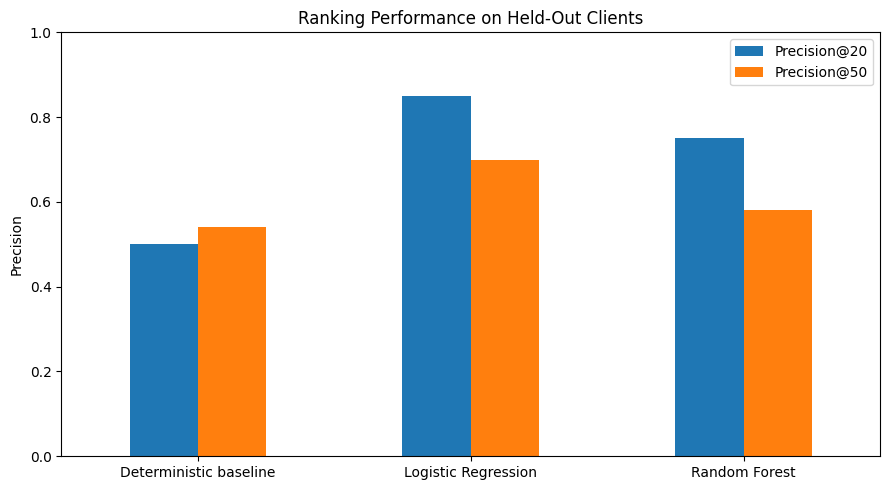

Saved figure: work/figures/model_vs_baseline_precision.png


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs(
    "work/figures",
    exist_ok=True,
)

plot_frame = results_table.set_index("Method")

ax = plot_frame.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Ranking Performance on Held-Out Clients"
)
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=0,
)

plt.tight_layout()

figure_path = (
    "work/figures/"
    "model_vs_baseline_precision.png"
)

plt.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

### Results

All methods were evaluated on the same grouped-client holdout, with zero client overlap between training and testing.

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| Deterministic baseline | 0.500 | 0.540 |
| Logistic Regression | 0.850 | 0.700 |
| Random Forest | 0.750 | 0.580 |

Logistic Regression produced the strongest measured ranking performance among the three methods tested. Its Precision@50 was 0.700, meaning that 35 of its top 50 ranked pages were observed to experience the defined April impressions decline. The deterministic baseline identified 27 of 50, while Random Forest identified 29 of 50.

At Precision@20, Logistic Regression identified 17 of 20 declining pages, compared with 10 of 20 for the baseline and 15 of 20 for Random Forest.

The result does not show that Logistic Regression is universally superior. It shows that, for this March-to-April dataset, five-feature design, and grouped-client validation split, the simpler Logistic Regression model produced the strongest measured ranking among the methods evaluated.

The Random Forest did not improve on Logistic Regression, which is a useful reminder that greater model complexity does not automatically produce a better decision-support ranking.

## 5. Limitations

*What this work cannot claim.*

### Limitations and honest framing

This study is a directional, decision-support analysis rather than a causal study.

The model was evaluated on one specific time transition: March 2026 features predicting an April 2026 decline label. The measured results should therefore not be assumed to transfer unchanged to every future month, client, topic, search environment, or season.

The target itself is a practical proxy. A page is labeled as declining when April impressions are more than 20% below March impressions. This definition is useful for prioritization, but it does not prove that the page has a permanent content problem.

The model uses only five search-performance features. It does not directly observe many factors that may influence performance, including:

- changes in search demand
- competitor activity
- SERP layout changes
- seasonality
- tracking or measurement changes
- site migrations or technical changes
- content quality and factual accuracy
- content age or freshness
- business importance
- user intent

For this reason, a high decline score should not be interpreted as proof that a page is stale, low quality, or in need of a rewrite.

The analysis identifies associations between March signals and the defined April outcome. It does not establish that changing CTR, rankings, content length, freshness, or any other feature would cause future performance to improve.

The grouped-client holdout reduces direct client leakage and provides a more demanding generalization test than a random page split, but it is still only one holdout split. Performance may vary under other valid client splits and future evaluation windows.

The baseline also has limitations. Many pages can receive identical baseline scores, especially pages with zero CTR. A deterministic tie-break based on March impressions was used to make the ranking reproducible and to prioritize pages with more existing visibility. This tie-break is a review-priority rule, not a claim that impressions cause decline.

Finally, the recommendations in this paper are intended for human review. The system should not automatically rewrite, publish, delete, redirect, deindex, or otherwise modify content based only on the model score.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The model output is converted into a human-reviewed content action playbook rather than an automated publishing system.

Pages are ranked by their Logistic Regression decline score. The score is then combined with simple, interpretable review rules to produce an action label and reason code.

The high-priority threshold is defined from the score distribution rather than from an arbitrary probability cutoff. Pages in the top 10% of decline scores are treated as high priority, while pages between the 60th and 90th percentile are treated as elevated priority.

The playbook uses four action categories:

- **REVIEW_CTR_AND_REFRESH**  
  Used when a page has a high decline score, ranks within the top 20 search positions, and has CTR below the training-set median for similar positions.  
  Reason code: `HIGH_SCORE_LOW_CTR_FOR_POSITION`

- **REVIEW_CONTENT_AND_RANKING**  
  Used for other high-scoring pages where weak CTR is not the main visible signal.  
  Reason code: `HIGH_SCORE_OTHER_SIGNALS`

- **MONITOR_AND_REVIEW**  
  Used for pages with elevated, but not top-decile, decline scores.  
  Reason code: `ELEVATED_DECLINE_SCORE`

- **MONITOR**  
  Used for lower-scoring pages.  
  Reason code: `LOWER_DECLINE_SCORE`

These labels are review recommendations, not diagnoses. For example, `REVIEW_CTR_AND_REFRESH` does not mean that the model has detected stale content. The current model contains no explicit content-age or freshness feature. A human reviewer must inspect freshness, search intent, page quality, business value, tracking context, and other relevant factors before deciding whether any change is appropriate.

The intended workflow is:

**model ranking → reason code → human review → human decision → measured follow-up**

No content changes should be automated directly from these recommendations.

In [ ]:
test_actions = test_df.copy()

test_actions["decline_score"] = logistic_scores

# Position buckets
test_actions["position_bucket"] = pd.cut(
    test_actions["march_avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True,
)

# Training-only median CTR by position bucket
train_for_actions = train_df.copy()

train_for_actions["position_bucket"] = pd.cut(
    train_for_actions["march_avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True,
)

action_bucket_medians = (
    train_for_actions
    .groupby(
        "position_bucket",
        observed=True,
    )["march_ctr_pct"]
    .median()
)

test_actions["position_median_ctr"] = (
    test_actions["position_bucket"]
    .map(action_bucket_medians)
    .astype(float)
)

test_actions["weak_ctr"] = (
    test_actions["march_ctr_pct"]
    < test_actions["position_median_ctr"]
)

# Score-distribution thresholds
high_threshold = test_actions["decline_score"].quantile(0.90)
medium_threshold = test_actions["decline_score"].quantile(0.60)

def assign_action(row):
    if row["decline_score"] >= high_threshold:
        if (
            row["march_avg_position"] <= 20
            and row["weak_ctr"]
        ):
            return pd.Series(
                [
                    "REVIEW_CTR_AND_REFRESH",
                    "HIGH_SCORE_LOW_CTR_FOR_POSITION",
                ]
            )

        return pd.Series(
            [
                "REVIEW_CONTENT_AND_RANKING",
                "HIGH_SCORE_OTHER_SIGNALS",
            ]
        )

    if row["decline_score"] >= medium_threshold:
        return pd.Series(
            [
                "MONITOR_AND_REVIEW",
                "ELEVATED_DECLINE_SCORE",
            ]
        )

    return pd.Series(
        [
            "MONITOR",
            "LOWER_DECLINE_SCORE",
        ]
    )

test_actions[
    ["action_label", "reason_code"]
] = test_actions.apply(
    assign_action,
    axis=1,
)

action_queue = (
    test_actions
    .sort_values(
        by=[
            "decline_score",
            "content_hash_id",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

action_queue["priority_rank"] = (
    np.arange(len(action_queue)) + 1
)

print(
    f"High-priority threshold: "
    f"{high_threshold:.3f}"
)

print(
    f"Elevated-priority threshold: "
    f"{medium_threshold:.3f}"
)

print("\nAction counts:")

display(
    action_queue[
        ["action_label", "reason_code"]
    ]
    .value_counts()
    .rename("count")
    .reset_index()
)

High-priority threshold: 0.593
Elevated-priority threshold: 0.496

Action counts:


,action_label,reason_code,count
0,MONITOR,LOWER_DECLINE_SCORE,5013
1,MONITOR_AND_REVIEW,ELEVATED_DECLINE_SCORE,2507
2,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION,781
3,REVIEW_CONTENT_AND_RANKING,HIGH_SCORE_OTHER_SIGNALS,55


In [ ]:
public_preview = action_queue[
    [
        "priority_rank",
        "decline_score",
        "march_impressions",
        "march_clicks",
        "march_ctr_pct",
        "march_avg_position",
        "march_active_days",
        "action_label",
        "reason_code",
    ]
].head(10)

public_preview

,priority_rank,decline_score,march_impressions,march_clicks,march_ctr_pct,march_avg_position,march_active_days,action_label,reason_code
0,1,0.634635,992.0,0.0,0.0,0.663352,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
1,2,0.632474,447.0,0.0,0.0,1.926054,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
2,3,0.631453,256.0,0.0,0.0,2.514371,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
3,4,0.631304,1133.0,0.0,0.0,2.496049,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
4,5,0.631197,645.0,0.0,0.0,2.611243,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
5,6,0.631129,1499.0,0.0,0.0,2.550616,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
6,7,0.631064,587.0,0.0,0.0,2.691523,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
7,8,0.631015,842.0,0.0,0.0,2.689654,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
8,9,0.630770,698.0,0.0,0.0,2.841735,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION
9,10,0.630682,551.0,0.0,0.0,2.907586,31,REVIEW_CTR_AND_REFRESH,HIGH_SCORE_LOW_CTR_FOR_POSITION


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Paper artifacts

The deployed research page uses a small set of public-safe artifacts generated directly from this notebook.

The main results figure compares the deterministic baseline, Logistic Regression, and Random Forest on Precision@20 and Precision@50 using the same grouped-client holdout.

A second figure summarizes the action playbook by showing how many held-out pages fall into each recommended review category.

The ranked action queue itself is exported to `work/outputs/`, but private identifiers are not displayed on the public paper. The public page shows only aggregated results and public-safe example metrics.

These artifacts are regenerated from the notebook so that the paper remains traceable to the underlying analysis.

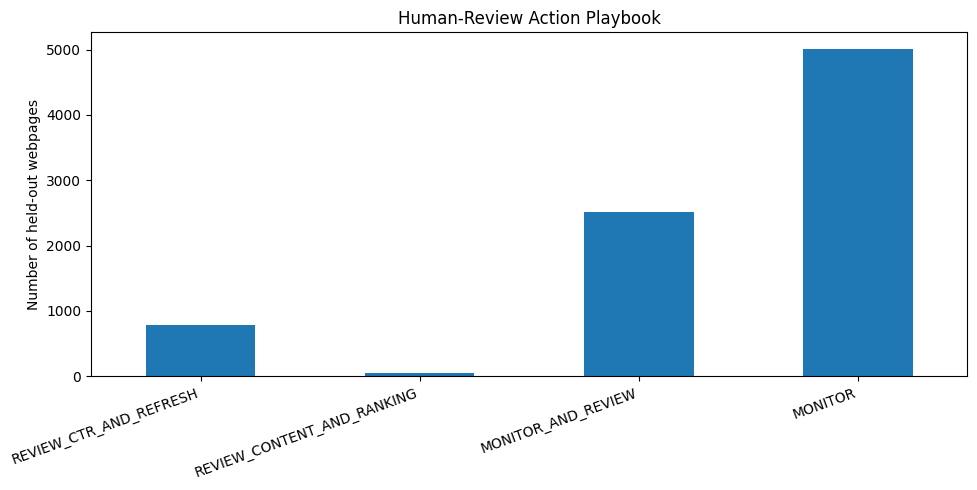

Saved figure: work/figures/action_playbook_distribution.png


In [ ]:
action_counts = (
    action_queue["action_label"]
    .value_counts()
    .reindex(
        [
            "REVIEW_CTR_AND_REFRESH",
            "REVIEW_CONTENT_AND_RANKING",
            "MONITOR_AND_REVIEW",
            "MONITOR",
        ]
    )
)

ax = action_counts.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Human-Review Action Playbook"
)

ax.set_ylabel(
    "Number of held-out webpages"
)

ax.set_xlabel("")

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

action_figure_path = (
    "work/figures/"
    "action_playbook_distribution.png"
)

plt.savefig(
    action_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {action_figure_path}"
)

In [ ]:
import json

os.makedirs(
    "work/outputs",
    exist_ok=True,
)

# Final results table
results_csv_path = (
    "work/outputs/"
    "capstone_model_results.csv"
)

results_table.to_csv(
    results_csv_path,
    index=False,
)

# Public-safe action summary
action_summary = (
    action_queue[
        ["action_label", "reason_code"]
    ]
    .value_counts()
    .rename("count")
    .reset_index()
)

action_summary_path = (
    "work/outputs/"
    "capstone_action_summary.csv"
)

action_summary.to_csv(
    action_summary_path,
    index=False,
)

# Compact metrics receipt for the paper
capstone_metrics = {
    "validation_design": "grouped_by_client_75_25",
    "client_overlap": int(client_overlap),

    "baseline": {
        "precision_at_20": float(baseline_p20),
        "precision_at_50": float(baseline_p50),
    },

    "logistic_regression": {
        "precision_at_20": float(logistic_p20),
        "precision_at_50": float(logistic_p50),
    },

    "random_forest": {
        "precision_at_20": float(rf_p20),
        "precision_at_50": float(rf_p50),
    },

    "selected_model": "logistic_regression",

    "high_priority_threshold": float(
        high_threshold
    ),

    "elevated_priority_threshold": float(
        medium_threshold
    ),

    "human_review_required": True,

    "automatic_content_changes_allowed": False,
}

metrics_path = (
    "work/outputs/"
    "capstone_metrics.json"
)

with open(
    metrics_path,
    "w",
) as f:
    json.dump(
        capstone_metrics,
        f,
        indent=2,
    )

print(
    f"Saved: {results_csv_path}"
)

print(
    f"Saved: {action_summary_path}"
)

print(
    f"Saved: {metrics_path}"
)

Saved: work/outputs/capstone_model_results.csv
Saved: work/outputs/capstone_action_summary.csv
Saved: work/outputs/capstone_metrics.json


In [ ]:
artifacts = [
    "work/figures/model_vs_baseline_precision.png",
    "work/figures/action_playbook_distribution.png",
    "work/outputs/capstone_model_results.csv",
    "work/outputs/capstone_action_summary.csv",
    "work/outputs/capstone_metrics.json",
]

print("Capstone artifacts:\n")

for path in artifacts:
    status = (
        "OK"
        if os.path.exists(path)
        else "MISSING"
    )

    print(
        f"{status:7} {path}"
    )

Capstone artifacts:

OK      work/figures/model_vs_baseline_precision.png
OK      work/figures/action_playbook_distribution.png
OK      work/outputs/capstone_model_results.csv
OK      work/outputs/capstone_action_summary.csv
OK      work/outputs/capstone_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ✔] Every section above is filled — markdown thinking AND the code that backs it
- [✔] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ✔] No client names, URLs, or private queries anywhere
- [ ✔] My claims use careful words: observed, measured, directional, decision-support
- [✔ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 8. Five-minute demo outline

### 0:00–0:45 — The question

FlyRank's content workflow creates a practical prioritization problem: when a content team manages many webpages, which pages should be reviewed first?

My research question was:

**Can search-performance signals observed during March 2026 help rank webpages that are more likely to experience a meaningful impressions decline in April 2026?**

The goal was not to automate content decisions. The goal was to create a useful review queue for a human content or SEO team.

### 0:45–1:45 — The method

I built a page-level dataset using five March-only search-performance features:

- impressions
- clicks
- click-through rate
- average search position
- active days

I defined a future decline as April impressions being more than 20% below March impressions.

I compared three approaches on the same grouped-client holdout:

1. a transparent CTR-based baseline
2. Logistic Regression
3. Random Forest

The client-grouped split had zero client overlap between training and testing, which reduced direct client leakage.

### 1:45–2:45 — One chart

I would show the **model-vs-baseline Precision@K chart**.

The main comparison was:

| Method | Precision@20 | Precision@50 |
|---|---:|---:|
| Deterministic baseline | 0.500 | 0.540 |
| Logistic Regression | 0.850 | 0.700 |
| Random Forest | 0.750 | 0.580 |

### 2:45–3:45 — One honest result

Logistic Regression produced the strongest measured ranking among the three tested methods on this grouped-client holdout.

At Precision@50, 35 of the top 50 Logistic Regression recommendations were observed to meet the defined April decline condition, compared with 27 of 50 for the deterministic baseline.

This does not mean Logistic Regression is universally better or that the model knows why a page declined. It is a measured result for this March-to-April dataset, feature design, and validation setup.

### 3:45–5:00 — One recommendation

The final output is a human-reviewed content action playbook.

Instead of automatically editing content, the model ranks pages and assigns review-oriented actions such as:

- `REVIEW_CTR_AND_REFRESH`
- `REVIEW_CONTENT_AND_RANKING`
- `MONITOR_AND_REVIEW`
- `MONITOR`

My main recommendation is to use the ranking as a **decision-support queue**: review the highest-priority pages first, inspect their actual content and context, and let a human decide whether any change is appropriate.

The intended workflow is:

**model ranking → reason code → human review → human decision → measured follow-up**

## 9. Shareable cuts

### Short social post

I recently completed a machine-learning capstone using the FlyRank ML Internship dataset to study a practical content-prioritization problem: which webpages should a content team review first?

I built a March-to-April ranking pipeline using five search-performance signals and compared a transparent CTR-based baseline with Logistic Regression and Random Forest on a grouped-client holdout. Logistic Regression produced the strongest measured ranking in this evaluation, reaching Precision@20 of 0.850 and Precision@50 of 0.700 versus 0.500 and 0.540 for the baseline.

The most useful part of the project was turning the model output into a human-reviewed action playbook rather than treating the score as an automated content decision. The work reinforced the importance of leakage-safe validation, reproducibility, and honest claim framing when building applied ML systems.

### Three-sentence employer-facing summary

I built a machine-learning ranking system for content-review prioritization using the FlyRank ML Internship dataset, with 101,441 page-level records across 44 pseudonymized clients and five March search-performance features. I compared a transparent CTR-based baseline, Logistic Regression, and Random Forest using a grouped-client holdout with zero client overlap; Logistic Regression achieved the strongest measured ranking with Precision@20 of 0.850 and Precision@50 of 0.700. I then converted the model output into a human-reviewed content action playbook designed to prioritize investigation without automating editorial decisions.